In [1]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
import os 

# Đường dẫn ảnh ground truth (gốc)
original_path = 'data/supervised/test/Bot_3_layer_0.png'

# Thư mục chứa các ảnh nhiễu
noisy_dir = 'degradation/test'
output_dir = 'noise_histogram_output'

# Tiền tố cần lọc
prefix = 'Bot_3_layer_0_speckle'

# Tạo thư mục lưu kết quả nếu chưa có
os.makedirs(output_dir, exist_ok=True)

# Đọc ảnh gốc
original = cv2.imread(original_path, cv2.IMREAD_GRAYSCALE)
assert original is not None, "❌ Không thể đọc ảnh gốc"

print("✅ Đã tải ảnh gốc.")

# Lặp qua các ảnh nhiễu có tiền tố phù hợp
for fname in sorted(os.listdir(noisy_dir)):
    if not fname.endswith('.png') or not fname.startswith(prefix):
        continue

    noisy_path = os.path.join(noisy_dir, fname)
    noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    
    if noisy is None:
        print(f"❌ Không thể đọc ảnh: {fname}")
        continue

    if original.shape != noisy.shape:
        print(f"⚠️ Kích thước không khớp cho: {fname}")
        continue

    # Vẽ histogram cho ảnh gốc
    plt.figure(figsize=(8, 5))
    plt.hist(original.ravel(), bins=50, color='green', alpha=0.7, edgecolor='black')
    plt.title(f'Ground Truth Histogram: {fname}', fontsize=13)
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Pixel Count')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # Lưu hình histogram của ảnh gốc
    save_name = fname.replace('.png', '_GT_histogram.png')
    save_path = os.path.join(output_dir, save_name)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"✅ Đã lưu biểu đồ ảnh gốc: {save_name}")
    
    # Vẽ histogram cho ảnh nhiễu
    plt.figure(figsize=(8, 5))
    plt.hist(noisy.ravel(), bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title(f'Noisy Image Histogram: {fname}', fontsize=13)
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Pixel Count')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # Lưu hình histogram của ảnh nhiễu
    save_name = fname.replace('.png', '_Noisy_histogram.png')
    save_path = os.path.join(output_dir, save_name)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()
    print(f"✅ Đã lưu biểu đồ ảnh nhiễu: {save_name}")


✅ Đã tải ảnh gốc.
✅ Đã lưu biểu đồ ảnh gốc: Bot_3_layer_0_speckle_0.050_GT_histogram.png
✅ Đã lưu biểu đồ ảnh nhiễu: Bot_3_layer_0_speckle_0.050_Noisy_histogram.png
✅ Đã lưu biểu đồ ảnh gốc: Bot_3_layer_0_speckle_0.100_GT_histogram.png
✅ Đã lưu biểu đồ ảnh nhiễu: Bot_3_layer_0_speckle_0.100_Noisy_histogram.png
✅ Đã lưu biểu đồ ảnh gốc: Bot_3_layer_0_speckle_0.150_GT_histogram.png
✅ Đã lưu biểu đồ ảnh nhiễu: Bot_3_layer_0_speckle_0.150_Noisy_histogram.png
✅ Đã lưu biểu đồ ảnh gốc: Bot_3_layer_0_speckle_0.175_GT_histogram.png
✅ Đã lưu biểu đồ ảnh nhiễu: Bot_3_layer_0_speckle_0.175_Noisy_histogram.png
✅ Đã lưu biểu đồ ảnh gốc: Bot_3_layer_0_speckle_0.200_GT_histogram.png
✅ Đã lưu biểu đồ ảnh nhiễu: Bot_3_layer_0_speckle_0.200_Noisy_histogram.png
✅ Đã lưu biểu đồ ảnh gốc: Bot_3_layer_0_speckle_0.225_GT_histogram.png
✅ Đã lưu biểu đồ ảnh nhiễu: Bot_3_layer_0_speckle_0.225_Noisy_histogram.png
✅ Đã lưu biểu đồ ảnh gốc: Bot_3_layer_0_speckle_0.250_GT_histogram.png
✅ Đã lưu biểu đồ ảnh nhiễu: B

In [29]:
!pip install --upgrade scikit-image


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   - -------------------------------------- 0.4/12.9 MB 10.9 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/12.9 MB 10.9 MB/s eta 0:00:02
   ----- ---------------------------------- 1.7/12.9 MB 11.0 MB/s eta 0:00:02
   ------ --------------------------------- 2.2/12.9 MB 11.0 MB/s eta 0:00:01
   -------- ------------------------------- 2.7/12.9 MB 10.6 MB/s eta 0:00:01
   --------- ------------------------------ 3.0/12.9 MB 10.5 MB/s eta 0:00:01
   --------- ------------------------------ 3.0/12.9 MB 10.5 MB/s eta 0:00:01
   --------- ------------------------------ 3.0/12.9 MB 10.5 MB/s eta 0:00:01
   --------- ------------------------------ 3.0/12.9 MB 10.5 MB/s eta 0:00:01
   --------- ------------------------------ 3.0/12.9 MB 10.5 MB/s eta 0:00:01
   --------- ------------------------------ 3.0/12.9 MB 10.5 MB/s eta 0:00:01

  You can safely remove it manually.


In [4]:
import os
import cv2
import numpy as np
import argparse
from pathlib import Path
from tqdm import tqdm
from typing import List, Tuple

def add_gaussian_noise(image: np.ndarray, noise_ratio: float) -> np.ndarray:
    """
    Add Gaussian noise to the image in monochrome.

    Args:
        image: Input image array
        mean: Mean of the Gaussian distribution
        stddev: Standard deviation of the Gaussian distribution

    Returns:
        Noisy image array
    """
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    print("Adding Gaussian noise...")
    print(image)
    gaussian_noise = np.random.normal(0, noise_ratio*255, image.shape)
    print(gaussian_noise)
    noisy_image = image + gaussian_noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

add_gaussian_noise(cv2.imread('data/supervised/test/Bot_3_layer_0.png'), 0.1)

Adding Gaussian noise...
[[4 0 6 ... 0 0 4]
 [5 4 4 ... 5 5 5]
 [4 5 5 ... 4 4 5]
 ...
 [3 5 4 ... 5 4 0]
 [0 0 5 ... 4 5 4]
 [0 0 0 ... 0 0 0]]
[[-1.63138937e+01 -1.89614923e+01  2.76250615e+01 ...  2.88686486e+00
   7.47531618e+00 -2.31300494e+01]
 [-1.63251187e+01  1.38122897e+00  4.96106751e+01 ...  2.33773497e+01
   4.51067060e+01 -1.27523610e+01]
 [-9.26734937e+00  7.78426355e+00 -3.78831880e+01 ... -1.32651864e+01
  -2.00833945e+01  8.34536108e+01]
 ...
 [-1.90781998e+01 -4.07861588e+01  7.20444059e+00 ... -1.06490761e+01
  -5.40176952e+01  2.29085092e+01]
 [-8.19893462e-02 -1.39257496e+01  1.94510203e+01 ...  2.54316946e+01
  -7.81894259e+00 -1.46480815e+01]
 [-6.63161758e+01 -3.20669226e+01 -5.61803663e+01 ... -6.28530485e+01
   3.93502114e-01  2.21725238e+01]]


array([[ 0,  0, 33, ...,  2,  7,  0],
       [ 0,  5, 53, ..., 28, 50,  0],
       [ 0, 12,  0, ...,  0,  0, 88],
       ...,
       [ 0,  0, 11, ...,  0,  0, 22],
       [ 0,  0, 24, ..., 29,  0,  0],
       [ 0,  0,  0, ...,  0,  0, 22]], dtype=uint8)

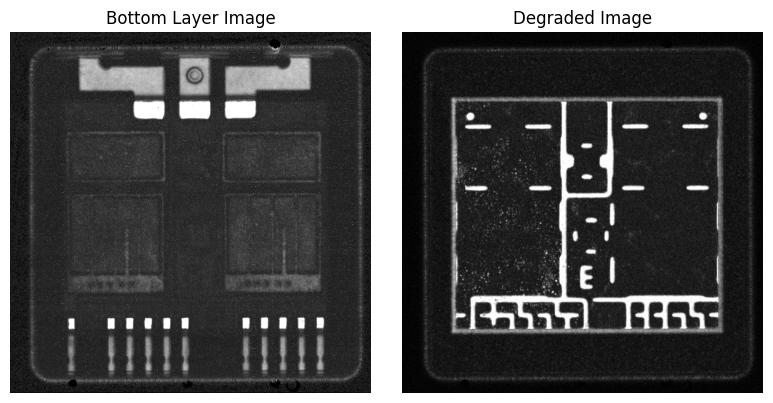

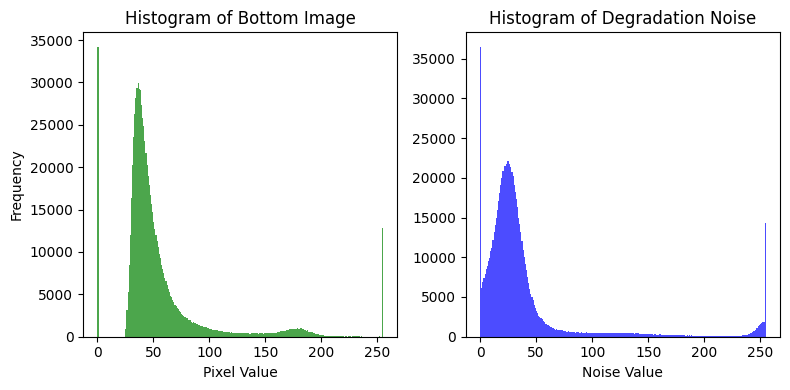

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Hàm thêm nhiễu Gaussian vào ảnh
def add_gaussian_noise(image: np.ndarray, noise_ratio: float):
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Sinh nhiễu Gaussian
    gaussian_noise = np.random.normal(0, noise_ratio * 255, image.shape)

    # Thêm nhiễu và giới hạn lại trong khoảng [0, 255]
    noisy_image = image + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

    return noisy_image, gaussian_noise

# Đọc ảnh gốc
image_dre = cv2.imread('data/supervised/test/Bot_3_layer_2.png', cv2.IMREAD_GRAYSCALE)
bottom_layer = cv2.imread('data/unsupervised/Bot_3_layer_7.png', cv2.IMREAD_GRAYSCALE)
# Thêm nhiễu Gaussian
noise_ratio = 0.025  # 3.5% cường độ nhiễu so với 255
noisy_image, gaussian_noise = add_gaussian_noise(image_dre, noise_ratio)

# =============================
# Hiển thị 3 ảnh: Gốc, Nhiễu, và Sau khi thêm nhiễu
# =============================
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(bottom_layer, cmap='gray')
plt.title('Bottom Layer Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title('Degraded Image')
plt.axis('off')

plt.tight_layout()
plt.show()

# =============================
# Vẽ 3 histogram tương ứng
# =============================
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.hist(bottom_layer.ravel(), bins=256, color='green', alpha=0.7)
plt.title('Histogram of Bottom Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(noisy_image.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Histogram of Degradation Noise')
plt.xlabel('Noise Value')


plt.tight_layout()
plt.show()


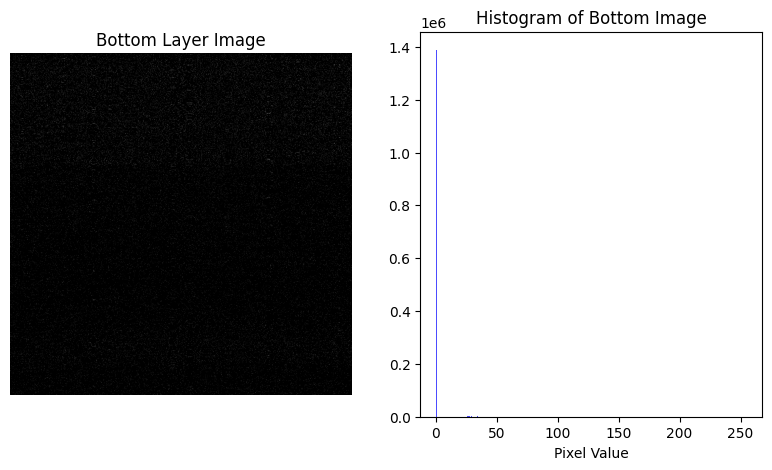

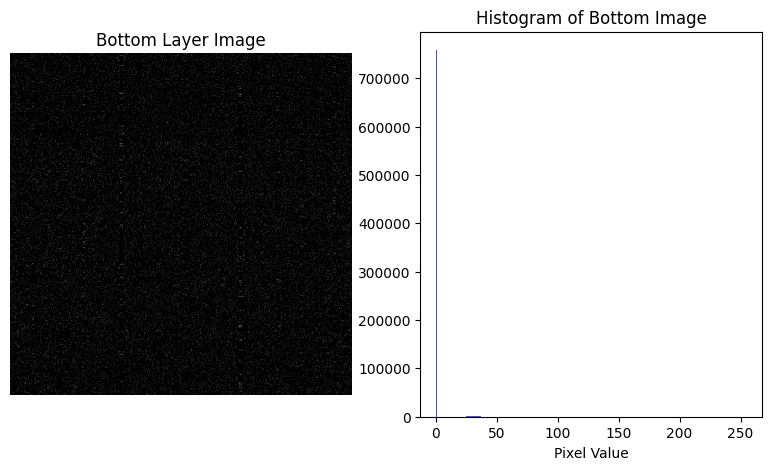

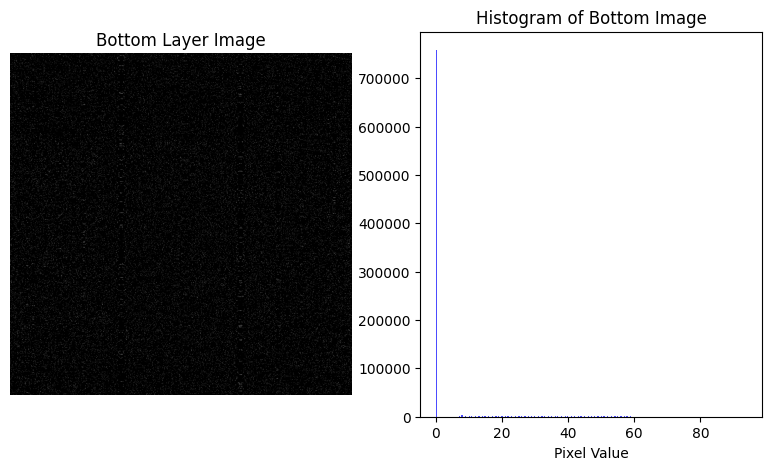

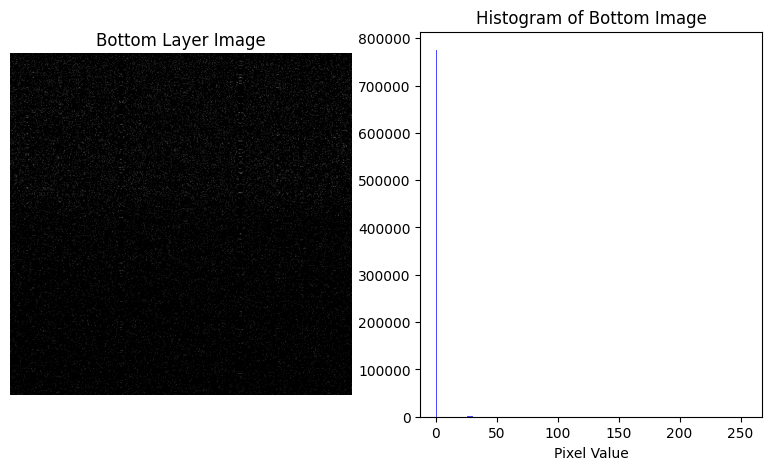

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob

for img_path in glob('data/ImageNoiseFromSAM/*.png'):
    # Đọc ảnh
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Bottom Layer Image')
    plt.axis('off')
    

    plt.subplot(1, 3, 2)
    plt.hist(img.ravel(), bins=256, color='blue', alpha=0.7)
    plt.title('Histogram of Bottom Image')
    plt.xlabel('Pixel Value')



    # plt.tight_layout()
    plt.show()

In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from matplotlib.backends.backend_pdf import PdfPages
import os

# Tên file PDF đầu ra
output_pdf_path = 'bottom_layer_images_and_histograms.pdf'

# Khởi tạo đối tượng PdfPages
with PdfPages(output_pdf_path) as pdf:
    for img_path in glob('data/unsupervised/*.png'):
        # Đọc ảnh xám
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Tạo figure mới
        plt.figure(figsize=(15, 5))

        # Hiển thị ảnh
        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap='gray')
        plt.title('Bottom Layer Image')
        plt.axis('off')

        # Histogram
        plt.subplot(1, 3, 2)
        plt.hist(img.ravel(), bins=256, color='blue', alpha=0.7)
        plt.title('Histogram of Bottom Image')
        plt.xlabel('Pixel Value')

        # Tên file gốc để chú thích (tùy chọn)
        filename = os.path.basename(img_path)
        plt.suptitle(f'File: {filename}', fontsize=12)

        # Ghi figure vào PDF
        pdf.savefig()
        plt.close()

print(f"✅ PDF saved to: {output_pdf_path}")


C:\Users\Nhan\AppData\Local\Temp\ipykernel_14756\88583174.py:38: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed two minor releases later.
  plt.close()


AttributeError: module 'numpy' has no attribute 'logical_or'

<Figure size 1500x500 with 0 Axes>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob

for img_path in glob('data/unsupervised/*.png'):
    # Đọc ảnh
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Tính histogram
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])

    # Vẽ histogram
    plt.plot(hist, color='blue')
    plt.xlim([0, 256])
    plt.title(f'Histogram of {img_path}')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()

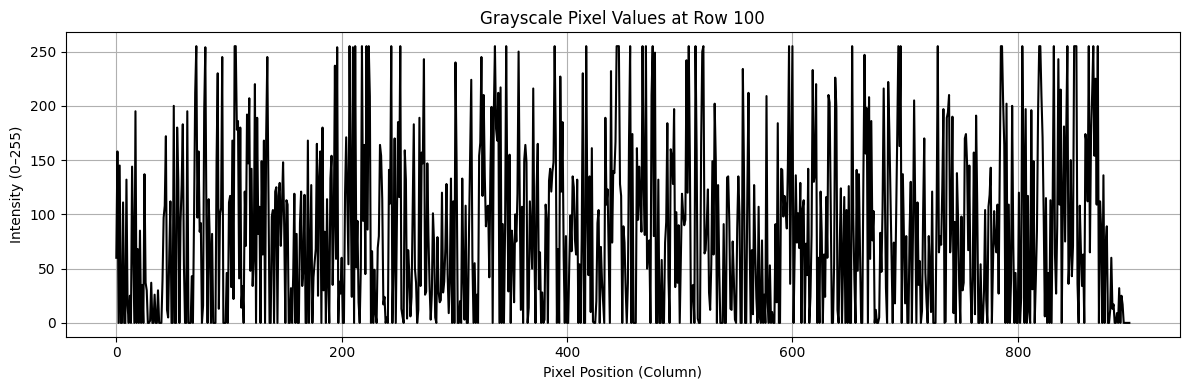

In [8]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('degradation/test/Bot_3_layer_1_gaussian_0.375.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 100
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='black')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


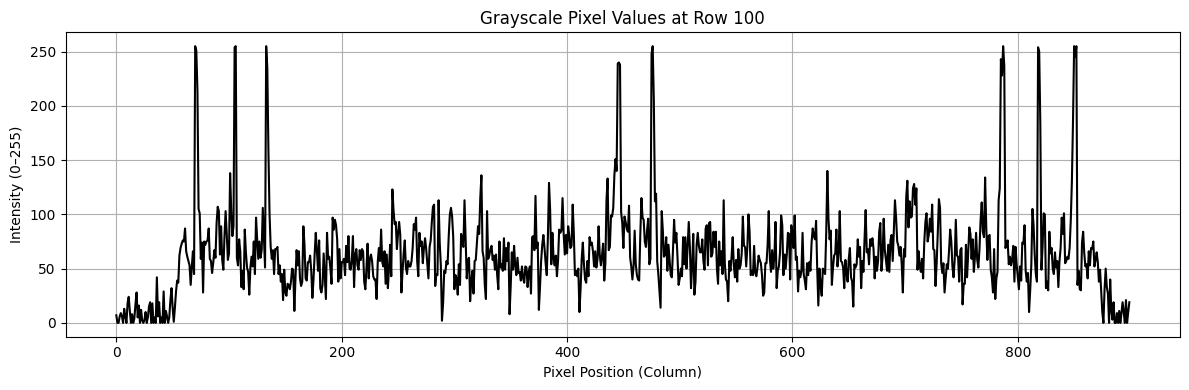

In [7]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('degradation/test/Bot_3_layer_1_gaussian_0.050.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 100
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='black')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


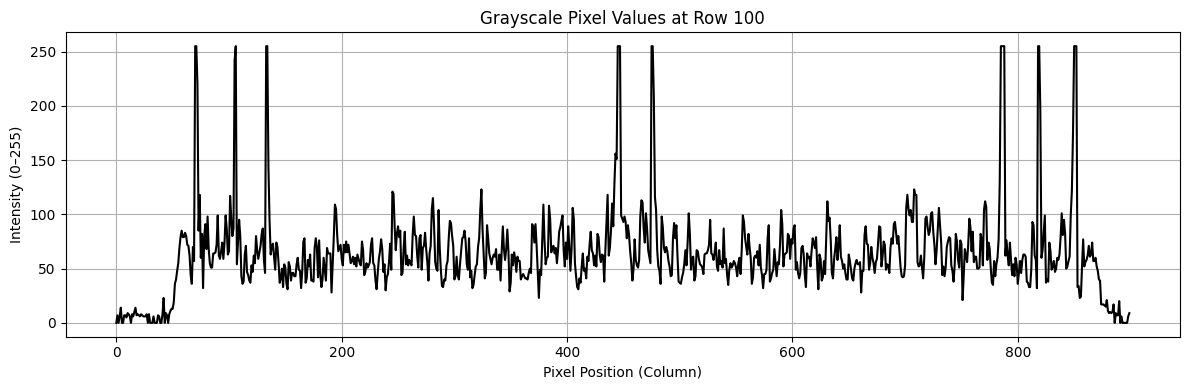

In [6]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('data/supervised/test/Bot_3_layer_1.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 100
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='black')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


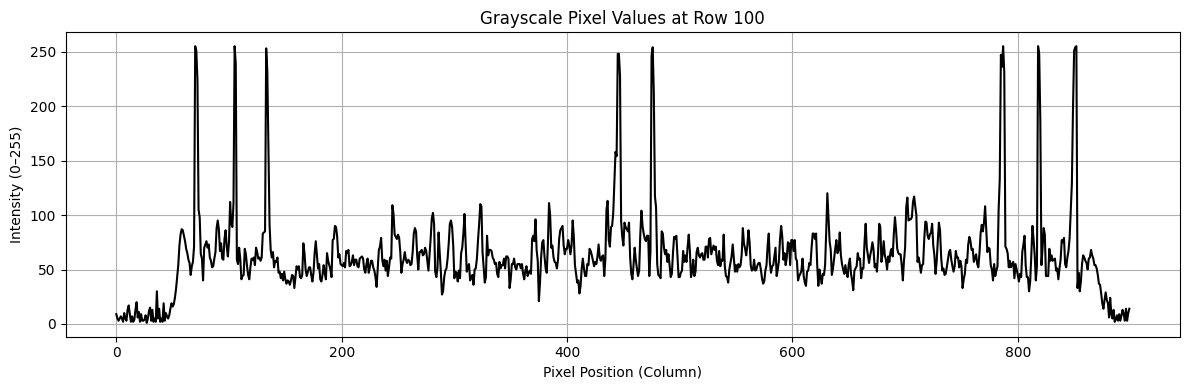

In [9]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('results/SAM540/Output/Bot_3_layer_1_gaussian_0.050.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 100
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='black')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


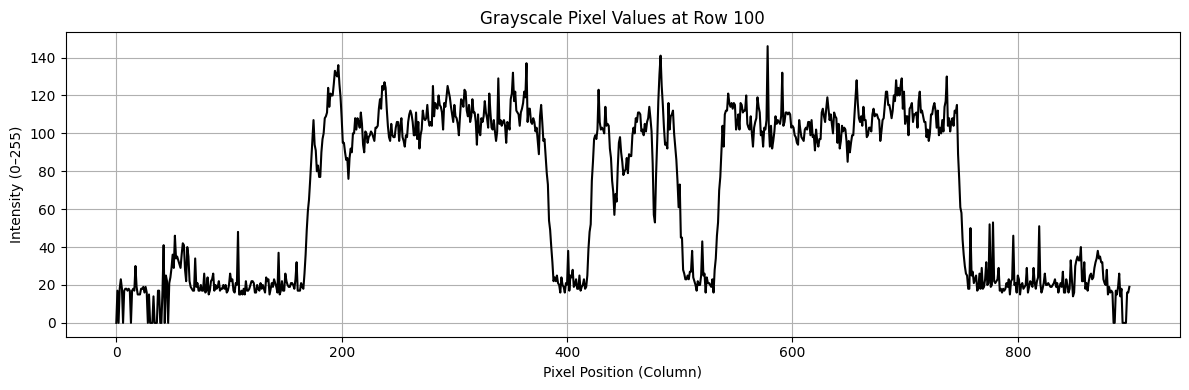

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('results/SAM36/Input/Bot_3_layer_6.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 100
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='black')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


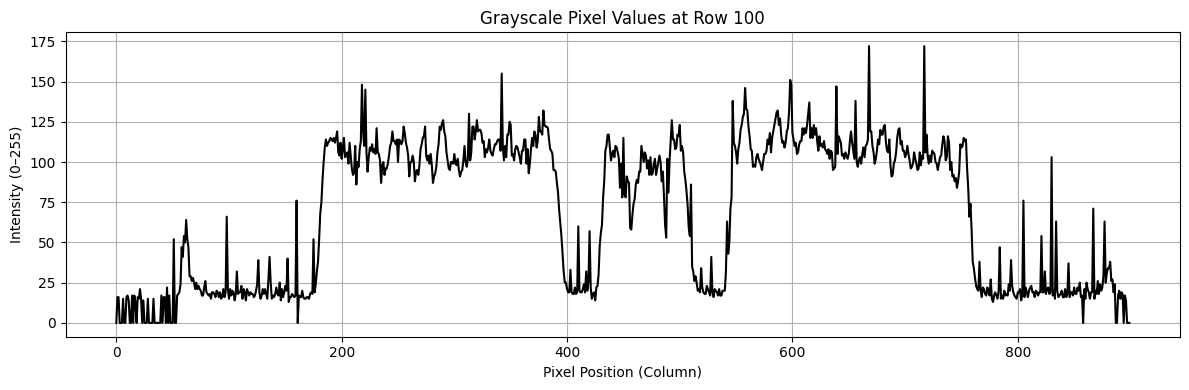

In [17]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('data/unsupervised/Bot_5_layer_6.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 100
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='black')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


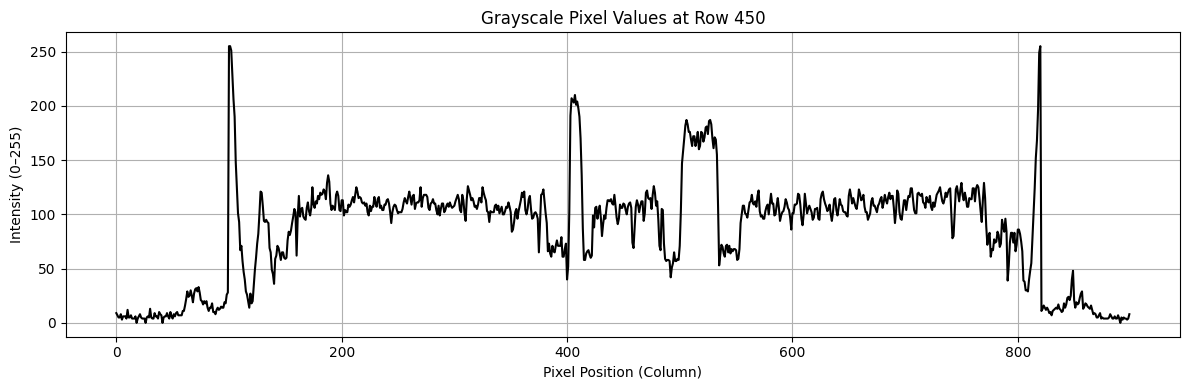

In [27]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('data/supervised/train/Top_12_layer_0.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 450
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='black')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


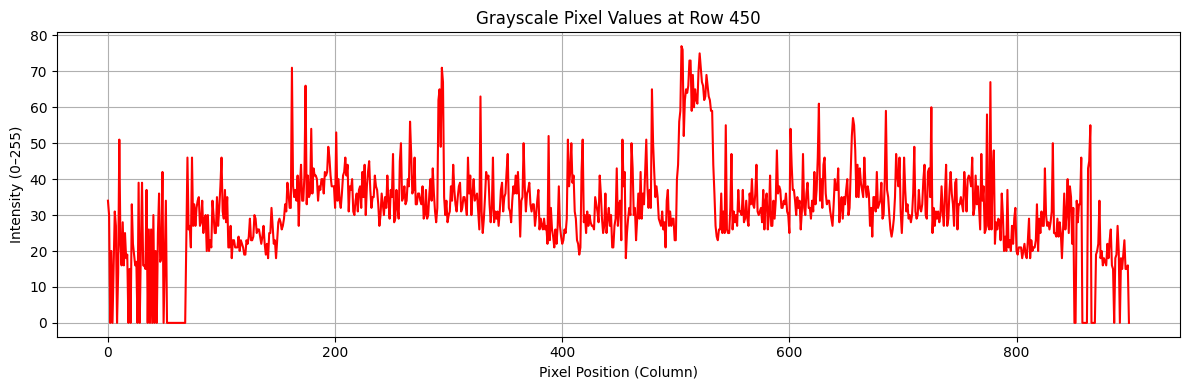

In [32]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('data/unsupervised/Top_12_layer_6.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 450
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='red')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


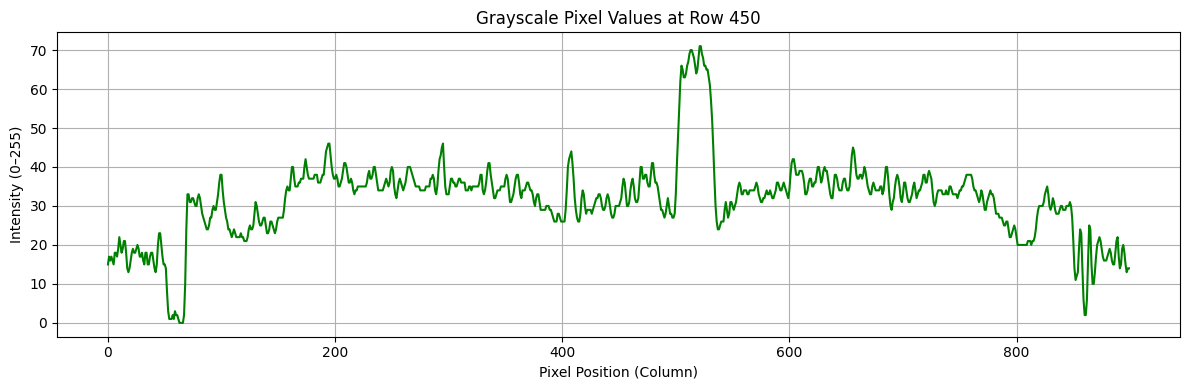

In [33]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('results/SAM36/Test_Image_Denoising_SAM18_Filter/visualization/SAMTest18/Top_12_layer_6.png', cv2.IMREAD_GRAYSCALE)

# Chọn một hàng cụ thể (ví dụ hàng 100)
row_index = 450
row_values = img[row_index, :]  # Dòng thứ 100, lấy toàn bộ cột

# Vẽ biểu đồ
plt.figure(figsize=(12, 4))
plt.plot(row_values, color='green')
plt.title(f'Grayscale Pixel Values at Row {row_index}')
plt.xlabel('Pixel Position (Column)')
plt.ylabel('Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
import cv2

img = cv2.imread("data/ImageNoiseFromSAM/Cu to Ceramic.png", cv2.IMREAD_GRAYSCALE)
pixels = img.flatten()


In [9]:
from scipy.stats import normaltest

stat, p_value = normaltest(pixels)
print(f"K² Statistic = {stat:.2f}, p-value = {p_value:.4f}")

if p_value > 0.05:
    print("✅ Pixel values likely follow a Gaussian distribution.")
else:
    print("❌ Pixel values do NOT follow a Gaussian distribution.")


K² Statistic = 1394474.09, p-value = 0.0000
❌ Pixel values do NOT follow a Gaussian distribution.


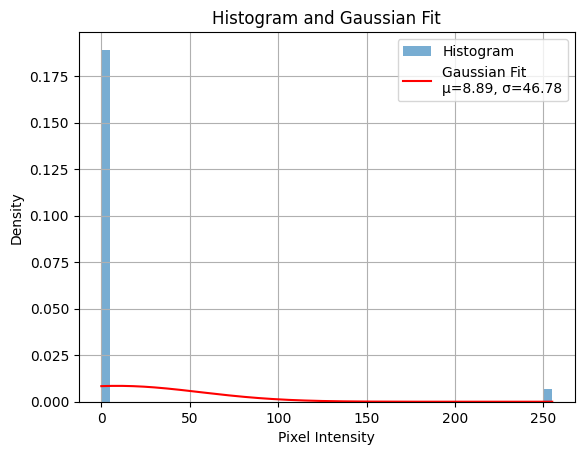

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, std = norm.fit(pixels)
x = np.linspace(0, 255, 256)
pdf = norm.pdf(x, mu, std)

plt.hist(pixels, bins=50, density=True, alpha=0.6, label='Histogram')
plt.plot(x, pdf, 'r-', label=f'Gaussian Fit\nμ={mu:.2f}, σ={std:.2f}')
plt.xlabel('Pixel Intensity')
plt.ylabel('Density')
plt.legend()
plt.title('Histogram and Gaussian Fit')
plt.grid(True)
plt.show()


In [1]:
!pip install noisemap

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for noisemap: filename=Noisemap-1.0-py3-none-any.whl size=2291 sha256=a396ccd5e179f31a8f92e3beeb3b3aa96e87d7ca5287bd82675be899e1a29d3c
  Stored in directory: C:\Users\Nhan\AppData\Local\Temp\pip-ephem-wheel-cache-awyckk7x\wheels\ec\df\f2\888ee245326592da8d413d101540a7c491b2e391ecebf39b3b
Successfully built noisemap


In [13]:
import cv2
import numpy as np

# Load image (replace 'your_image.jpg' with your image file)
img = cv2.imread('degradation/train/Bot_6_layer_8_gaussian_0.350.png', cv2.IMREAD_GRAYSCALE)
# img = cv2.resize(img, (100, 100))  # Resize for visualization if needed


In [ ]:
# Example: Gaussian-shaped noise map centered in the image
x = np.linspace(-1, 1, img.shape[1])
y = np.linspace(-1, 1, img.shape[0])
X, Y = np.meshgrid(x, y)
noise_map = np.exp(-(X**2 + Y**2) * 5)  # Sharper peak in center
# https://www.perplexity.ai/search/when-i-read-some-papaer-about-wQG78W2sSNij9Pzu.nolmw

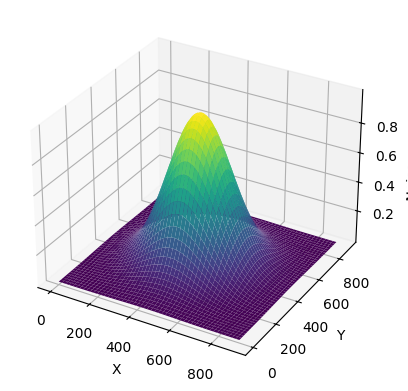

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(np.arange(noise_map.shape[1]), np.arange(noise_map.shape[0]))
ax.plot_surface(X, Y, noise_map, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Noise Level')
plt.show()
